In [1]:
import os
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START,END, StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage
from langgraph.graph.message import add_messages
from langchain_community.embeddings import HuggingFaceEmbeddings


c:\Users\mendh\Langchain-Langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
docs = WebBaseLoader("https://lilianweng.github.io/posts/2024-07-07-hallucination/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
db = FAISS.from_documents(chunks, embeddings)
retriever = db.as_retriever()

C:\Users\mendh\AppData\Local\Temp\ipykernel_20808\1033357308.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2024-07-07-hallucination/', 'title': "Extrinsic Hallucinations in LLMs | Lil'Log", 'description': 'Hallucination in large language models usually refers to the model generating unfaithful, fabricated, inconsistent, or nonsensical content. As a term, hallucination has been somewhat generalized to cases when the model makes mistakes. Here, I would like to narrow down the problem of hallucination to cases where the model output is fabricated and not grounded by either the provided context or world knowledge.\nThere are two types of hallucination:\n\nIn-context hallucination: The model output should be consistent with the source content in context.\nExtrinsic hallucination: The model output should be grounded by the pre-training dataset. However, given the size of the pre-training dataset, it is too expensive to retrieve and identify conflicts per generation. If we consider the pre-training data corpus as a proxy for world k

In [4]:
retriever.invoke("How to Detect Hallucination ")

[Document(id='b8ec9201-1876-4f84-97ce-dde8b3e0fce5', metadata={'source': 'https://lilianweng.github.io/posts/2024-07-07-hallucination/', 'title': "Extrinsic Hallucinations in LLMs | Lil'Log", 'description': 'Hallucination in large language models usually refers to the model generating unfaithful, fabricated, inconsistent, or nonsensical content. As a term, hallucination has been somewhat generalized to cases when the model makes mistakes. Here, I would like to narrow down the problem of hallucination to cases where the model output is fabricated and not grounded by either the provided context or world knowledge.\nThere are two types of hallucination:\n\nIn-context hallucination: The model output should be consistent with the source content in context.\nExtrinsic hallucination: The model output should be grounded by the pre-training dataset. However, given the size of the pre-training dataset, it is too expensive to retrieve and identify conflicts per generation. If we consider the pre-

In [5]:
def retriver_tool_func(query):
    print("Using RAGRetriver tool")
    print(f"Query is {query}")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [6]:
print(retriver_tool_func("How to Detect Hallucination"))

Using RAGRetriver tool
Query is How to Detect Hallucination
Anti-Hallucination Methods#
Let’s review a set of methods to improve factuality of LLMs, ranging from retrieval of external knowledge base, special sampling methods to alignment fine-tuning. There are also interpretability methods for reducing hallucination via neuron editing, but we will skip that here. I may write about interpretability in a separate post later.
RAG → Edits and Attribution#
FAVABench (Mishra et al. 2024) is a benchmark for evaluating fine-grained hallucination. There are 200 information-seeking source prompts and 3 model responses per prompt, resulting in 600 responses in total. Each model response is manually labeled with fine-grained annotations on hallucination error types.
Citation#
Cited as:
The evaluation framework for the FactualityPrompt benchmark.(Image source: Lee, et al. 2022)

Given the model continuation and paired Wikipedia text, two evaluation metrics for hallucination are considered:
These em

In [7]:
retriver_tool = Tool(
    name="RAGRetriver",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriver_tool_func
)


In [8]:
wiki_tool = WikipediaQueryRun(api_wrapper = WikipediaAPIWrapper())

In [9]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model("groq:qwen/qwen3-32b") 

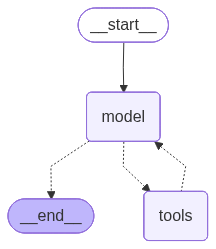

In [10]:
from langchain.agents import create_agent

tools = [retriver_tool,wiki_tool]

react_node = create_agent(llm,tools)
react_node

In [11]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]


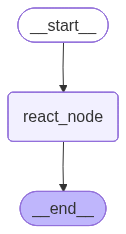

In [12]:
builder = StateGraph(AgentState)

builder.add_node("react_node",react_node)
builder.add_edge(START,'react_node')
builder.add_edge("react_node",END)

graph = builder.compile()
graph

In [18]:
query = "How to Detect Hallucination in LLM and what is machine learning"

state = {"messages":[HumanMessage(content=query)]}

result = graph.invoke(state)

print(result["messages"][-1].content)

Using RAGRetriver tool
Query is methods to detect hallucination in large language models
### **Detecting Hallucination in Large Language Models (LLMs)**  
Hallucination in LLMs refers to generating fabricated, inconsistent, or ungrounded content. Key detection methods include:  

1. **In-Context Hallucination Detection**:  
   - Verify if the model’s output aligns with the provided context. For example, if the context states "Paris is the capital of France," the model should not claim "Paris is in Germany."  

2. **Self-RAG (Retrieval-Augmented Generation)**:  
   - Combines retrieval, generation, and self-critique to ensure outputs are grounded in retrieved knowledge (Asai et al., ICLR 2024).  

3. **Fine-Grained Hallucination Detection**:  
   - Identifies specific factual errors in outputs using algorithms like those proposed by Mishra et al. (arXiv:2401.06855).  

4. **SelfCheckGPT**:  
   - A zero-resource black-box method that leverages internal model consistency checks to detect